In [4]:
import pandas as pd

In [5]:
import matplotlib.pylot as plt

ModuleNotFoundError: No module named 'matplotlib.pylot'

## Library Installation

Initial attempts to import pandas and matplotlib resulted in a `ModuleNotFoundError`.
This occurred because the required libraries were not installed in the Python environment.

The issue was resolved by installing the necessary packages using pip, after which the libraries imported successfully.


In [6]:
!pip install pandas matplotlib openpyxl

Defaulting to user installation because normal site-packages is not writeable


In [7]:
import pandas as pd
import matplotlib.pyplot as plt

In [8]:
df = pd.read_excel(r"C:\Users\glsee\OneDrive\Documents\data analysis\portfolio\UK Household Income & Inequality Trends (1977-2024).xlsx")
df.head()

,Year,Bottom,Top,All\n Individuals,Difference between top and bottom,YoY percentage increase
0,1977,9253,28942,16311,19689,0.0000
1,1978,10062,30968,18045,20906,0.0618
2,1979,10301,32866,18742,22565,0.0794
3,1980,10324,34541,19345,24217,0.0732
4,1981,10119,33907,18367,23788,-0.0177


In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 52 entries, 0 to 51
Data columns (total 6 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Year                               52 non-null     object 
 1                 Bottom               52 non-null     int64  
 2                Top                   52 non-null     int64  
 3   All
 Individuals                   52 non-null     int64  
 4   Difference between top and bottom  52 non-null     int64  
 5   YoY percentage increase            52 non-null     float64
dtypes: float64(1), int64(4), object(1)
memory usage: 2.6+ KB


In [10]:
df.columns

Index(['Year', '              Bottom', '             Top', 'All\n Individuals',
       'Difference between top and bottom', 'YoY percentage increase'],
      dtype='str')

## Data Loading Issue

The initial dataset loaded into Python corresponded to the first sheet in the Excel file, which contained a dashboard rather than structured data.

To correct this, the appropriate sheet containing the cleaned dataset was explicitly selected when loading the file. This ensured that subsequent analysis was performed on the correct data.


In [11]:
df = pd.read_excel(r"C:\Users\glsee\OneDrive\Documents\data analysis\portfolio\UK Household Income & Inequality Trends (1977-2024).xlsx", 
                    sheet_name="for python"
)

df.head()

,Year,Bottom,Top,All\n Individuals,Difference between top and bottom,YoY percentage increase
0,1977,9253,28942,16311,19689,0.0000
1,1978,10062,30968,18045,20906,0.0618
2,1979,10301,32866,18742,22565,0.0794
3,1980,10324,34541,19345,24217,0.0732
4,1981,10119,33907,18367,23788,-0.0177


In [12]:
df.columns

Index(['Year', '              Bottom', '             Top', 'All\n Individuals',
       'Difference between top and bottom', 'YoY percentage increase'],
      dtype='str')

In [13]:
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace("\n", " ", regex=False) 
    .str.replace(" ", "_")
    .str.replace("/", "_", regex=False)
)

df.columns

Index(['year', 'bottom', 'top', 'all__individuals',
       'difference_between_top_and_bottom', 'yoy_percentage_increase'],
      dtype='str')

In [14]:
df["income_gap"] = df ["top"] - df ["bottom"]

In [15]:
df[["year", "bottom", "top", "income_gap"]].head()

,year,bottom,top,income_gap
0,1977,9253,28942,19689
1,1978,10062,30968,20906
2,1979,10301,32866,22565
3,1980,10324,34541,24217
4,1981,10119,33907,23788


In [16]:
df["income_ratio"] = df["top"] / df["bottom"]

In [17]:
df[["year", "bottom", "top", "income_ratio"]].head()

,year,bottom,top,income_ratio
0,1977,9253,28942,3.127850
1,1978,10062,30968,3.077718
2,1979,10301,32866,3.190564
3,1980,10324,34541,3.345699
4,1981,10119,33907,3.350825


ValueError: could not convert string to float: '1994/95'

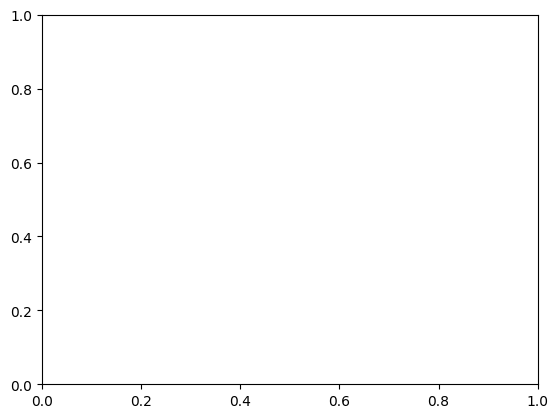

In [18]:
plt.figure()

plt.plot(df["year"], df["income_gap"])

plt.title("Income Gap Over Time")
plt.xlabel("Year")
plt.ylabel("Income Gap")

plt.xticks(rotation=45)

plt.show()

## Data Type Conversion

A ValueError occurred when attempting to generate visualisations. This was caused by numeric columns being stored as text due to formatting in the original Excel file.

The issue was resolved by converting relevant columns (e.g. year, quartiles) to numeric types using pandas, enabling successful plotting.


In [ ]:
df.dtypes

In [19]:
df[["year", "bottom", "top", "income_gap", "income_ratio"]].head(10)

,year,bottom,top,income_gap,income_ratio
0,1977,9253,28942,19689,3.127850
1,1978,10062,30968,20906,3.077718
2,1979,10301,32866,22565,3.190564
3,1980,10324,34541,24217,3.345699
4,1981,10119,33907,23788,3.350825
5,1982,10052,32758,22706,3.258854
6,1983,10008,35189,25181,3.516087
7,1984,10476,34752,24276,3.317297
8,1985,10182,38792,28610,3.809861
9,1986,10592,39279,28687,3.708365


In [20]:
df["year"] = pd.to_numeric(df["year"], errors="coerce")
df["bottom"] = pd.to_numeric(df["bottom"], errors="coerce")
df["top"] = pd.to_numeric(df["top"], errors="coerce")

df["income_gap"] = df["top"] - df["bottom"]
df["income_ratio"] = df["top"] / df["bottom"]

In [21]:
df = df.dropna(subset=["year", "income_gap"])

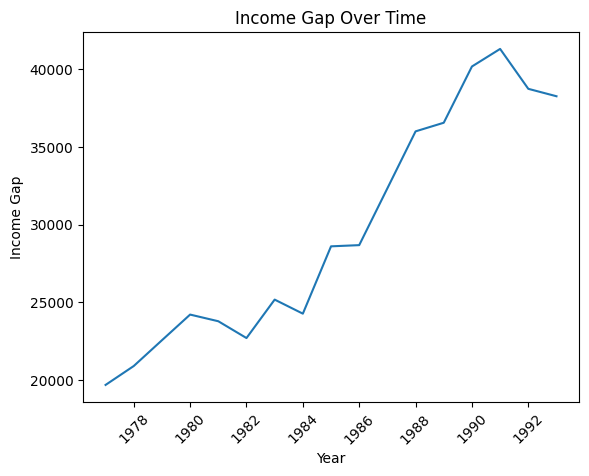

In [22]:
plt.figure()

plt.plot(df["year"], df["income_gap"])

plt.title("Income Gap Over Time")
plt.xlabel("Year")
plt.ylabel("Income Gap")

plt.xticks(rotation=45)
plt.show()

## Handling Time Format Inconsistencies

The initial visualisations only displayed data up to 1993. This was due to inconsistent formatting in the year column, where later observations were recorded as financial years (e.g. 1994/95).

To address this, the dataset was reviewed and cleaned to ensure a continuous time series. The year values were standardised to a consistent numeric format, allowing the full time range to be visualised.


In [23]:
df["year"].head(20)
df["year"].tail(20)

0     1977.0
1     1978.0
2     1979.0
3     1980.0
4     1981.0
5     1982.0
6     1983.0
7     1984.0
8     1985.0
9     1986.0
10    1987.0
11    1988.0
12    1989.0
13    1990.0
14    1991.0
15    1992.0
16    1993.0
Name: year, dtype: float64

In [24]:
df["year"].isna().sum()

np.int64(0)

In [25]:
df = df.sort_values("year")

In [26]:
df["year"].head(20)
df["year"].tail(20)

0     1977.0
1     1978.0
2     1979.0
3     1980.0
4     1981.0
5     1982.0
6     1983.0
7     1984.0
8     1985.0
9     1986.0
10    1987.0
11    1988.0
12    1989.0
13    1990.0
14    1991.0
15    1992.0
16    1993.0
Name: year, dtype: float64

In [27]:
df["year"].min(), df["year"].max()

(np.float64(1977.0), np.float64(1993.0))

In [28]:
df["year"].tail(20)

0     1977.0
1     1978.0
2     1979.0
3     1980.0
4     1981.0
5     1982.0
6     1983.0
7     1984.0
8     1985.0
9     1986.0
10    1987.0
11    1988.0
12    1989.0
13    1990.0
14    1991.0
15    1992.0
16    1993.0
Name: year, dtype: float64

In [29]:
df["year"].min(), df["year"].max()

(np.float64(1977.0), np.float64(1993.0))

In [30]:
df["year"] = df["year"].astype(str).str.extract(r"(\d{4})", expand=False)
df["year"] = pd.to_numeric(df["year"], errors="coerce")

df = df.dropna(subset=["year"])
df = df.sort_values("year")

In [31]:
df["year"].tail(20)

0     1977
1     1978
2     1979
3     1980
4     1981
5     1982
6     1983
7     1984
8     1985
9     1986
10    1987
11    1988
12    1989
13    1990
14    1991
15    1992
16    1993
Name: year, dtype: int64

In [32]:
df["year"].min(), df["year"].max()

(np.int64(1977), np.int64(1993))

In [33]:
df["year"].unique()

array([1977, 1978, 1979, 1980, 1981, 1982, 1983, 1984, 1985, 1986, 1987,
       1988, 1989, 1990, 1991, 1992, 1993])

In [34]:
df = pd.read_excel(r"C:\Users\glsee\OneDrive\Documents\data analysis\portfolio\UK Household Income & Inequality Trends (1977-2024).xlsx", 
                    sheet_name="for python"
)

df.head(20)

,Year,Bottom,Top,All\n Individuals,Difference between top and bottom,YoY percentage increase
0,1977,9253,28942,16311,19689,0.0000
1,1978,10062,30968,18045,20906,0.0618
2,1979,10301,32866,18742,22565,0.0794
3,1980,10324,34541,19345,24217,0.0732
4,1981,10119,33907,18367,23788,-0.0177
5,1982,10052,32758,18083,22706,-0.0455
6,1983,10008,35189,18272,25181,0.1090
7,1984,10476,34752,18847,24276,-0.0359
8,1985,10182,38792,19676,28610,0.1785
9,1986,10592,39279,20474,28687,0.0027


In [35]:
df["year"].unique()

KeyError: 'year'

In [36]:
df.columns

Index(['Year', '              Bottom', '             Top', 'All\n Individuals',
       'Difference between top and bottom', 'YoY percentage increase'],
      dtype='str')

In [37]:
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace("\n", " ", regex=False)
    .str.replace(" ", "_")
    .str.replace("/", "_", regex=False)
)

df.columns

Index(['year', 'bottom', 'top', 'all__individuals',
       'difference_between_top_and_bottom', 'yoy_percentage_increase'],
      dtype='str')

In [38]:
df["year"].unique()

array([1977, 1978, 1979, 1980, 1981, 1982, 1983, 1984, 1985, 1986, 1987,
       1988, 1989, 1990, 1991, 1992, 1993, '1994/95', '1995/96',
       '1996/97', '1997/98', '1998/99', '1999/00', '2000/01', '2001/02',
       '2002/03', '2003/04', '2004/05', '2005/06', '2006/07', '2007/08',
       '2008/09', '2009/10', '2010/11', '2011/12', '2012/13', '2013/14',
       '2014/15', '2015/16', '2016/17', '2017/18', '2018/19', '2019/20',
       '2020/21', '2021/22', '2022/23', '2023/24'], dtype=object)

In [39]:
df["income_gap"] = df ["top"] - df ["bottom"]

In [40]:
df["income_ratio"] = df["top"] / df["bottom"]

In [41]:
df[["year", "bottom", "top", "income_gap", "income_ratio"]].head(10)

,year,bottom,top,income_gap,income_ratio
0,1977,9253,28942,19689,3.127850
1,1978,10062,30968,20906,3.077718
2,1979,10301,32866,22565,3.190564
3,1980,10324,34541,24217,3.345699
4,1981,10119,33907,23788,3.350825
5,1982,10052,32758,22706,3.258854
6,1983,10008,35189,25181,3.516087
7,1984,10476,34752,24276,3.317297
8,1985,10182,38792,28610,3.809861
9,1986,10592,39279,28687,3.708365


In [42]:
df[["year", "bottom", "top", "income_gap", "income_ratio"]].tail(10)

,year,bottom,top,income_gap,income_ratio
42,2019/20,17692,75445,57753,4.264357
43,2020/21,17345,74724,57379,4.308100
44,2021/22,16889,75945,59056,4.496714
45,2022/23,17275,72220,54945,4.180608
46,2023/24,16832,71077,54245,4.222731
47,2019/20,17692,75445,57753,4.264357
48,2020/21,17345,74724,57379,4.308100
49,2021/22,16889,75945,59056,4.496714
50,2022/23,17275,72220,54945,4.180608
51,2023/24,16832,71077,54245,4.222731


ValueError: could not convert string to float: '1994/95'

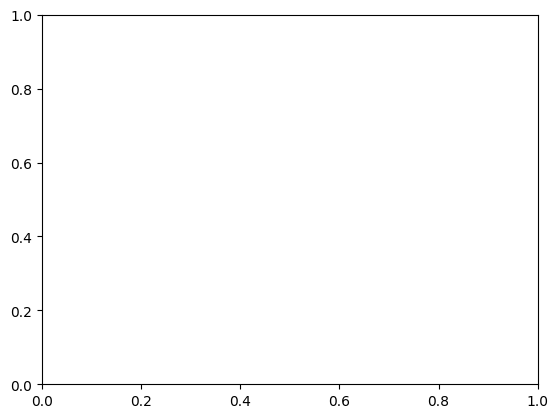

In [43]:
plt.figure()

plt.plot(df["year"], df["income_gap"])

plt.title("Income Gap Over Time")
plt.xlabel("Year")
plt.ylabel("Income Gap")

plt.xticks(rotation=45)
plt.show()

## Resolving Plotting Errors

A subsequent ValueError occurred during plotting due to inconsistencies in the dataset, particularly in the later years.

This required revisiting earlier cleaning steps, ensuring that all relevant columns were correctly formatted and free from invalid or missing values. Reapplying the cleaning process resolved the issue and enabled successful visualisation.


In [44]:
!pip install pandas matplotlib openpyxl

Defaulting to user installation because normal site-packages is not writeable


In [45]:
import pandas as pd

In [46]:
import matplotlib.pyplot as plt

In [47]:
df = pd.read_excel(r"C:\Users\glsee\OneDrive\Documents\data analysis\portfolio\UK Household Income & Inequality Trends (1977-2024).xlsx", sheet_name="for python")

In [48]:
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace("\n", " ", regex=False)
    .str.replace(" ", "_")
    .str.replace("/", "_", regex=False)
)

df["year"] = df["year"].astype(str).str.extract(r"(\d{4})", expand=False)
df["year"] = pd.to_numeric(df["year"], errors="coerce")

df["top"] = (
    df["top"].astype(str).str.replace(",", "", regex=False).str.strip()
)
df["bottom"] = (
    df["bottom"].astype(str).str.replace(",", "", regex=False).str.strip()
)

df["top"] = pd.to_numeric(df["top"], errors="coerce")
df["bottom"] = pd.to_numeric(df["bottom"], errors="coerce")

df["income_gap"] = df["top"] - df["bottom"]
df["income_ratio"] = df["top"] / df["bottom"]

df = df.dropna(subset=["year", "top", "bottom", "income_gap"])
df = df.sort_values("year")

print(df["year"].min(), df["year"].max())
print(df[["year", "top", "bottom", "income_gap"]].tail(10))

1977 2023
    year    top  bottom  income_gap
42  2019  75445   17692       57753
47  2019  75445   17692       57753
43  2020  74724   17345       57379
48  2020  74724   17345       57379
49  2021  75945   16889       59056
44  2021  75945   16889       59056
50  2022  72220   17275       54945
45  2022  72220   17275       54945
46  2023  71077   16832       54245
51  2023  71077   16832       54245


In [49]:
df.head(20)

,year,bottom,top,all__individuals,difference_between_top_and_bottom,yoy_percentage_increase,income_gap,income_ratio
0,1977,9253,28942,16311,19689,0.0000,19689,3.127850
1,1978,10062,30968,18045,20906,0.0618,20906,3.077718
2,1979,10301,32866,18742,22565,0.0794,22565,3.190564
3,1980,10324,34541,19345,24217,0.0732,24217,3.345699
4,1981,10119,33907,18367,23788,-0.0177,23788,3.350825
5,1982,10052,32758,18083,22706,-0.0455,22706,3.258854
6,1983,10008,35189,18272,25181,0.1090,25181,3.516087
7,1984,10476,34752,18847,24276,-0.0359,24276,3.317297
8,1985,10182,38792,19676,28610,0.1785,28610,3.809861
9,1986,10592,39279,20474,28687,0.0027,28687,3.708365


In [50]:
df.tail(20)

,year,bottom,top,all__individuals,difference_between_top_and_bottom,yoy_percentage_increase,income_gap,income_ratio
32,2009,17029,72837,33591,55808,0.0438,55808,4.277233
33,2010,17405,70578,33544,53173,-0.0472,53173,4.055042
34,2011,17186,68471,32758,51285,-0.0355,51285,3.984115
35,2012,16412,68239,32007,51827,0.0106,51827,4.157872
36,2013,16698,69705,32830,53007,0.0228,53007,4.174452
37,2014,17023,72280,34255,55257,0.0424,55257,4.246020
38,2015,18006,71281,34854,53275,-0.0359,53275,3.958736
39,2016,18653,72692,35794,54039,0.0143,54039,3.897067
40,2017,17136,73073,34938,55937,0.0351,55937,4.264297
41,2018,16247,74211,35224,57964,0.0362,57964,4.567674


In [51]:
df[df["year"] >= 2019].head(20)

,year,bottom,top,all__individuals,difference_between_top_and_bottom,yoy_percentage_increase,income_gap,income_ratio
42,2019,17692,75445,36671,57753,-0.0036,57753,4.264357
47,2019,17692,75445,36671,57753,0.0647,57753,4.264357
43,2020,17345,74724,37414,57379,-0.0065,57379,4.308100
48,2020,17345,74724,37414,57379,-0.0065,57379,4.308100
49,2021,16889,75945,37306,59056,0.0292,59056,4.496714
44,2021,16889,75945,37306,59056,0.0292,59056,4.496714
50,2022,17275,72220,36384,54945,-0.0696,54945,4.180608
45,2022,17275,72220,36384,54945,-0.0696,54945,4.180608
46,2023,16832,71077,36663,54245,-0.0127,54245,4.222731
51,2023,16832,71077,36663,54245,-0.0127,54245,4.222731


In [52]:
df[df["year"] == 2019].T

,42,47
year,2019.000000,2019.000000
bottom,17692.000000,17692.000000
top,75445.000000,75445.000000
all__individuals,36671.000000,36671.000000
difference_between_top_and_bottom,57753.000000,57753.000000
yoy_percentage_increase,-0.003600,0.064700
income_gap,57753.000000,57753.000000
income_ratio,4.264357,4.264357


In [53]:
df = df.drop_duplicates(subset=["year", "top", "bottom"])

In [54]:
df["year"].value_counts().sort_index().tail(10)

year
2014    1
2015    1
2016    1
2017    1
2018    1
2019    1
2020    1
2021    1
2022    1
2023    1
Name: count, dtype: int64

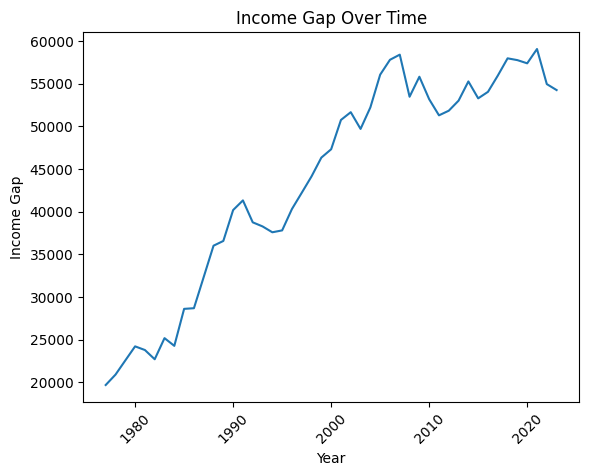

In [55]:
plt.figure()

plt.plot(df["year"], df["income_gap"])

plt.title("Income Gap Over Time")
plt.xlabel("Year")
plt.ylabel("Income Gap")

plt.xticks(rotation=45)

plt.show()

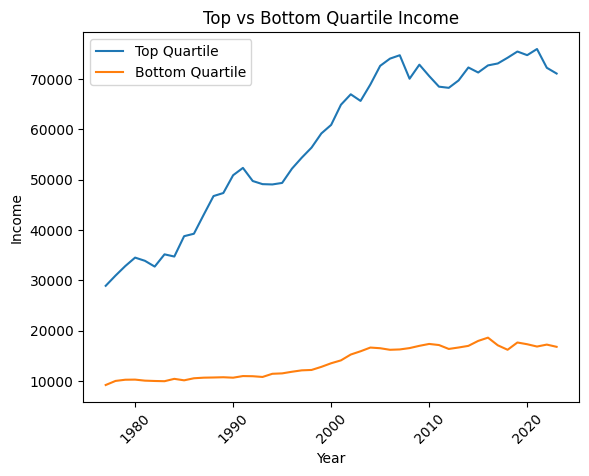

In [56]:
plt.figure()

plt.plot(df["year"], df["top"], label="Top Quartile")
plt.plot(df["year"], df["bottom"], label="Bottom Quartile")

plt.title("Top vs Bottom Quartile Income")
plt.xlabel("Year")
plt.ylabel("Income")

plt.legend()
plt.xticks(rotation=45)

plt.show()

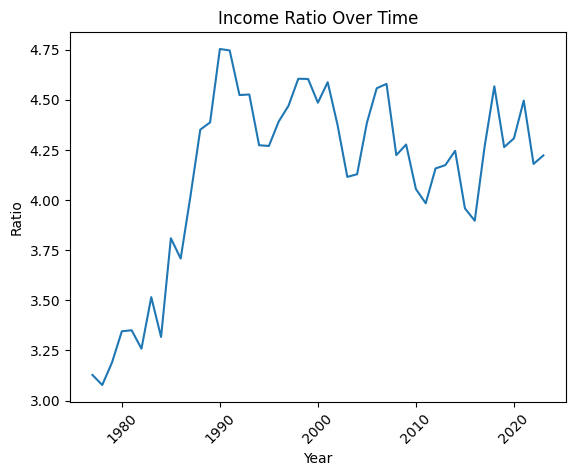

In [57]:
plt.figure()

plt.plot(df["year"], df["income_ratio"])

plt.title("Income Ratio Over Time")
plt.xlabel("Year")
plt.ylabel("Ratio")

plt.xticks(rotation=45)

plt.show()

## UK Household Income Analysis (Python)

## Overview 
This project analyses UK household income trends using ONS data, focusing on income distribution and inequality over time.

## Data Source
Office for National Statistics (ONS) – Effects of Taxes and Benefits on Household Income.

## Challenges and Learning

This project involved working with real-world data, which required handling inconsistent formats, missing values, and duplicate records.

Through this process, key skills developed included data cleaning, debugging Python errors, and ensuring data consistency for analysis and visualisation.

## Import Libraries

The analysis uses pandas for data manipulation and matplotlib for data visualisation. These libraries enable efficient handling of tabular data and the creation of time-series plots.

## Load Data

The dataset is loaded from an Excel file containing UK household income data. The relevant sheet is selected to ensure that only structured tabular data is used for analysis, excluding dashboard or formatted sheets.

## Data Cleaning

The dataset required several cleaning steps to ensure it was suitable for analysis. Column names were standardised for consistency, and numeric columns were converted from text to appropriate data types.

The year column contained a mix of standard and financial year formats, which were standardised to a single numeric format. Duplicate rows caused by differences in non-essential columns were also removed to ensure one observation per year.

## Feature Engineering

Additional variables were created to support analysis of income inequality.

* Income gap: the difference between the top and bottom quartiles
* Income ratio: the relative difference between top and bottom quartiles

These measures provide both absolute and relative perspectives on income distribution over time.

## Visualisation

Line charts were created to explore trends in income distribution over time. The visualisations focus on:

* Changes in the income gap
* Differences between top and bottom quartiles
* The income ratio as a measure of inequality

These charts allow for clear identification of long-term trends and variations in income inequality.

## Insights
- The income gap between top and bottom quartiles changes over time, indicating variation in inequality.
- Higher-income households consistently earn significantly more than lower-income households.
- The income ratio suggests persistent inequality across the time period.
- There are periods where the gap widens more rapidly, suggesting shifts in income distribution.

In [1]:
import os
os.getcwd()

'C:\\Users\\glsee'

In [2]:
import os
os.listdir()

['.ipynb_checkpoints',
 '.ipython',
 '.jupyter',
 '.matplotlib',
 'AppData',
 'Application Data',
 'Contacts',
 'Cookies',
 'Documents',
 'Downloads',
 'Favorites',
 'Links',
 'Local Settings',
 'Music',
 'My Documents',
 'NetHood',
 'NTUSER.DAT',
 'ntuser.dat.LOG1',
 'ntuser.dat.LOG2',
 'NTUSER.DAT{57f3839e-1c80-11f0-a921-faf153b1d7bc}.TM.blf',
 'NTUSER.DAT{57f3839e-1c80-11f0-a921-faf153b1d7bc}.TMContainer00000000000000000001.regtrans-ms',
 'NTUSER.DAT{57f3839e-1c80-11f0-a921-faf153b1d7bc}.TMContainer00000000000000000002.regtrans-ms',
 'ntuser.ini',
 'OneDrive',
 'PrintHood',
 'Recent',
 'Saved Games',
 'Searches',
 'SendTo',
 'Start Menu',
 'Templates',
 'uk_income_analysis',
 'Untitled.ipynb',
 'untitled.py',
 'Untitled1.ipynb',
 'Untitled2.ipynb',
 'Videos']

In [3]:
import os
print(os.path.abspath("uk_income_analysis.ipynb"))

C:\Users\glsee\uk_income_analysis.ipynb


In [4]:
import shutil
shutil.copy("uk_income_analysis.ipynb", r"C:\Users\glsee\Desktop\uk_income_analysis.ipynb")

FileNotFoundError: [Errno 2] No such file or directory: 'uk_income_analysis.ipynb'

In [2]:
[f for f in os.listdir() if f.endswith(".ipynb")]

NameError: name 'os' is not defined

In [3]:
import os

In [4]:
[f for f in os.listdir() if f.endswith(".ipynb")]

['uk_income_analysis.ipynb',
 'Untitled.ipynb',
 'Untitled1.ipynb',
 'Untitled2.ipynb']

In [6]:
import shutil
shutil.copy("uk_income_analysis.ipynb", r"C:\Users\glsee\Desktop\uk_income_analysis.ipynb")

FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\glsee\\Desktop\\uk_income_analysis.ipynb'

In [7]:
import os
files = [f for f in os.listdir() if f.endswith(".ipynb")]
print(files)

['uk_income_analysis.ipynb', 'Untitled.ipynb', 'Untitled1.ipynb', 'Untitled2.ipynb']


In [8]:
import shutil
file_name = [f for f in os.listdir() if f.endswith(".ipynb")][-1]
print(file_name)
shutil.copy(file_name, r"C:\Users\glsee\Desktop\\" + file_name)

Untitled2.ipynb


FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\glsee\\Desktop\\\\Untitled2.ipynb'

In [9]:
import os
import shutil

# find all notebooks
files = [f for f in os.listdir() if f.endswith(".ipynb")]
print("Notebook files:", files)

# pick the most recently modified one
latest_file = max(files, key=os.path.getmtime)
print("Using file:", latest_file)

# copy to Desktop
shutil.copy(latest_file, r"C:\Users\glsee\Desktop\\" + latest_file)

Notebook files: ['uk_income_analysis.ipynb', 'Untitled.ipynb', 'Untitled1.ipynb', 'Untitled2.ipynb']
Using file: uk_income_analysis.ipynb


FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\glsee\\Desktop\\\\uk_income_analysis.ipynb'

In [10]:
os.getcwd()

'C:\\Users\\glsee'

In [11]:
import os
import shutil

files = [f for f in os.listdir() if f.endswith(".ipynb")]
print(files)

latest_file = max(files, key=os.path.getmtime)
print("Using file:", latest_file)

desktop = os.path.join(os.path.expanduser("~"), "Desktop")
print("Desktop path:", desktop)
print("Desktop exists:", os.path.exists(desktop))

shutil.copy(latest_file, os.path.join(desktop, latest_file))
print("Copied successfully")

['uk_income_analysis.ipynb', 'Untitled.ipynb', 'Untitled1.ipynb', 'Untitled2.ipynb']
Using file: uk_income_analysis.ipynb
Desktop path: C:\Users\glsee\Desktop
Desktop exists: False


FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\glsee\\Desktop\\uk_income_analysis.ipynb'

In [12]:
import os
import shutil

# Current folder
cwd = os.getcwd()
print("Current folder:", cwd)

# Notebook files in this folder
files = [f for f in os.listdir(cwd) if f.endswith(".ipynb")]
print("Notebook files:", files)

# Pick the newest one
latest_file = max(files, key=lambda f: os.path.getmtime(os.path.join(cwd, f)))
print("Using file:", repr(latest_file))

# Build absolute source path
source_path = os.path.join(cwd, latest_file)
print("Source path:", source_path)
print("Source exists:", os.path.exists(source_path))

# Try a very simple destination we know should exist
dest_path = os.path.join(cwd, "copied_notebook.ipynb")
print("Destination path:", dest_path)

shutil.copy2(source_path, dest_path)
print("Copied successfully")

Current folder: C:\Users\glsee
Notebook files: ['uk_income_analysis.ipynb', 'Untitled.ipynb', 'Untitled1.ipynb', 'Untitled2.ipynb']
Using file: 'uk_income_analysis.ipynb'
Source path: C:\Users\glsee\uk_income_analysis.ipynb
Source exists: True
Destination path: C:\Users\glsee\copied_notebook.ipynb
Copied successfully
